# Practice — Core Code Patterns, from One Call to an Agent Loop

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ralbu85/stml_2026/blob/main/lectures/week05/W5_practice_core_patterns_v2.ipynb)

**Goal.** Write, without looking them up, the code every lab is built from: (1) one call, (2) a conversation, (3) a prompt template in a function, (4) JSON output, (5) a tool call, (6) the agent loop, (7) ReAct, and (8) an agent kept in a class. The tools are easy ones: live weather, a calculator, and Wikipedia search.

**One way to write every call.** Every call in this notebook is the same three lines:

```python
response = client.chat.completions.create(model=MODEL, messages=messages)   # call the model with the list
reply = response.choices[0].message.model_dump(exclude_none=True)           # the model's reply, as a dictionary
messages.append(reply)                                                       # keep it as it arrived
```

Then you check the key of `reply`: a text answer has `"content"`; a tool request (Part 5 on) has `"tool_calls"`. You type only the messages you write (system, user, tool). The model's reply is never retyped.

**Cell labels.** The first line of each code cell says what to do with it:

- `# ✍️ TYPE` — an exercise: write the code between the `FILL IN` lines yourself.
- `# ✍️ WRITE` — answer in words (not checked).
- `# ▶ RUN · example` — the pattern being taught: read each line, then run.
- `# ▶ RUN · setup` or `# ▶ RUN · check` — support cells: just run.

About 80 minutes. Not collected. Needs basic Python: lists, dictionaries, functions, `for` loops, `if`, f-strings.

## 0. Setup

*Do:* run the four cells; paste your API key into the second. The third defines `show_messages`, which prints the message list: each message's position, role, and content (for a request, the requested function). The fourth sends a first call and prints `ready`.

In [ ]:
# ▶ RUN · setup: just run
%pip install -q "openai==1.109.1"

In [ ]:
# ▶ RUN · setup: just run
import os

OPENAI_API_KEY = "PASTE-YOUR-KEY-HERE"   # paste your key between the quotes
if OPENAI_API_KEY != "PASTE-YOUR-KEY-HERE":
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY   # the client reads the key from here

In [ ]:
# ▶ RUN · setup: just run
import json
from openai import OpenAI

client = OpenAI()                  # the OpenAI library; reads OPENAI_API_KEY from the environment
MODEL = "gpt-4.1"
done = {}                          # the check cells record your results here


def show_messages(messages):
    """Print each message: position, role, and content."""
    for i in range(len(messages)):
        m = messages[i]
        if "tool_calls" in m:                          # a request: print each requested function
            for call in m["tool_calls"]:
                print(i, m["role"], call["function"])
        else:
            print(i, m["role"], m["content"])
    print()

In [ ]:
# ▶ RUN · setup: just run
messages = [{"role": "user", "content": "Reply with exactly: ready"}]
response = client.chat.completions.create(model=MODEL, messages=messages)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)
reply["content"]

## 1. One Call: Call the Model, Keep the Reply

```python
messages = [{"role": "user", "content": QUESTION}]                           # the list you send
response = client.chat.completions.create(model=MODEL, messages=messages)   # call the model with the list
reply = response.choices[0].message.model_dump(exclude_none=True)           # the model's reply, as a dictionary
messages.append(reply)                                                       # keep it as it arrived
answer = reply["content"]                                                    # the text answer
```

- `messages` is the list you send. Every message in it is a dictionary with a `"role"`.
- `response` is what the API returns. `response.choices[0].message` is the model's reply; `.model_dump(exclude_none=True)` gives it as a dictionary and leaves out its empty fields. So `reply` has the same shape as the messages you write.
- `messages.append(reply)` keeps the reply in the list exactly as it arrived.
- The keys of `reply` say what it holds. A text answer is under `"content"`.

### 1.1 One call

*Do:* run the cell. `print(reply)` shows the dictionary: `role`, `content`, and `annotations` (a list of web citations, empty here). The list now holds two messages.

In [ ]:
# ▶ RUN · example: read each line, then run
QUESTION = "In one sentence, what is a cancelled order in an online shop?"
messages = [{"role": "user", "content": QUESTION}]
response = client.chat.completions.create(model=MODEL, messages=messages)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)
answer = reply["content"]

print(reply)
print(answer)
show_messages(messages)

**Reading the output.** The first printed line is `reply`, the model's message as a dictionary:

```python
{'content': 'A cancelled order in an online shop is ...',   # the text answer
 'role': 'assistant',                                       # who wrote it: the model
 'annotations': []}                                         # web citations; empty here
```

`reply` came out of `response` like this:

```text
response                                  the whole result of the call (an object)
 └─ choices                               a list of replies; one by default
     └─ [0]                               the first reply
         └─ message                       the model's message (an object)
             └─ .model_dump(exclude_none=True)  ->  reply, a dictionary
```

The last lines come from `show_messages(messages)`: line `0` is your question (`messages[0]`), typed by you; line `1` is `reply` (`messages[1]`), kept as it arrived. Both are dictionaries with a `"role"`, so they sit in the same list.

### 1.2 ✍️ Your first call

*Do:* the question and the list are given; write the three call lines and read the answer. Expected: `PASS`, and 2 messages in the list.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
QUESTION = "Reply with exactly: PASS"
messages = [{"role": "user", "content": QUESTION}]
answer = None
### FILL IN (START) ###
# send the list, keep the reply, read the answer
### FILL IN (END) ###

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)
done["1.2"] = answer == "PASS" and len(messages) == 2
done["1.2"]

## 2. A Conversation: the List Grows

A call sees only the list you send; the model keeps nothing between calls. To continue a conversation, add your next message to the same list and send the whole list again. Each message's **role** says who wrote it:

| Kind | In the code | Written by | Holds |
|---|---|---|---|
| **System** message | `{"role": "system", "content": ...}`, first in the list | you, once | standing instructions for the whole conversation |
| **User** message | `{"role": "user", "content": ...}` | you, for each request | the question or task, with any data it needs |
| **Assistant** message | `reply`, kept with `messages.append(reply)` | the model | a text answer, or tool requests (Part 5) |
| **Tool** message | `{"role": "tool", "tool_call_id": ..., "content": ...}` | your program (Part 5) | the result of a requested function |
| **Tool schema** | `tools=TOOLS`, next to `messages`, not in it | you (Part 5) | a function the model may request |

An **instruction** applies where you put it: in the system message, to every turn; in a user message, to that request; in a tool schema, whenever the model considers that tool.

### 2.1 Two turns

*Do:* run the four cells one by one. Units 2 and 4 are the same code: add nothing new, just call the model and keep the reply.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - the list: a system message and a user message
STAFF_SYSTEM = "You answer questions from shop staff. Answer in at most two sentences."
QUESTION = "A customer ordered 2 mugs and 1 desk lamp. List the items in the order."

messages = [
    {"role": "system", "content": STAFF_SYSTEM},     # SYSTEM message
    {"role": "user", "content": QUESTION},           # USER message
]
show_messages(messages)

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 2 - call the model, read the answer
response = client.chat.completions.create(model=MODEL, messages=messages)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)                               # ASSISTANT message
answer = reply["content"]
show_messages(messages)

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 3 - add the next question
messages.append({"role": "user", "content": "The lamp was cancelled. What is left in the order?"})   # USER message
show_messages(messages)

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 4 - call the model, read the answer (the same code as unit 2)
response = client.chat.completions.create(model=MODEL, messages=messages)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)                               # ASSISTANT message
answer = reply["content"]
show_messages(messages)

**Reading the output.** After two turns the list holds five messages:

| Position | Role | Written by | How it got into the list |
|---|---|---|---|
| `[0]` | system | you | typed in unit 1 |
| `[1]` | user | you | typed in unit 1 |
| `[2]` | assistant | the model | `messages.append(reply)` in unit 2 |
| `[3]` | user | you | typed in unit 3 |
| `[4]` | assistant | the model | `messages.append(reply)` in unit 4 |

User and assistant messages alternate. Unit 4 sent the whole list, so the second question could say only "the lamp": the model read the order in `[1]` and `[2]`. To rerun, start again from unit 1, or the list grows twice.

### 2.2 ✍️ One more turn

*Do:* the next question and the call are given; write the two lines that make `reply` and keep it. Expected: 7 messages, and an answer that lists the mugs and the notebooks.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
messages.append({"role": "user", "content": "The customer adds 3 notebooks. What is in the order now?"})
response = client.chat.completions.create(model=MODEL, messages=messages)
### FILL IN (START) ###
# the reply as a dictionary, kept in the list
### FILL IN (END) ###
answer = reply["content"]

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)
roles = []
for m in messages:
    roles.append(m["role"])
done["2.2"] = roles == ["system", "user", "assistant", "user", "assistant", "user", "assistant"] and "notebook" in answer.lower() and "mug" in answer.lower()
done["2.2"]

## 3. A Prompt Template inside a Function

A call written many times goes into a function. The body of `ask` is the Part 1 cell; the list is made inside, so every call to `ask` starts a new list.

```python
def ask(prompt):
    messages = [{"role": "user", "content": prompt}]
    response = client.chat.completions.create(model=MODEL, messages=messages)
    reply = response.choices[0].message.model_dump(exclude_none=True)
    messages.append(reply)
    return reply["content"]

text = ask(f"Describe a {product}.")           # f-string: {product} is replaced by its value
review = ask(f"Critique this text:\n{text}")   # the first output is part of the second prompt
```

The instruction and the data travel together in one **user** message. Later labs write one such function per step or role, for example draft, critique, and revision.

### 3.1 Define `ask` and fill a template

*Do:* run the cell. Change `product` and run it again.

In [ ]:
# ▶ RUN · example: read each line, then run
def ask(prompt):
    """Send one user message and return the text answer."""
    messages = [{"role": "user", "content": prompt}]          # USER message: instruction + data
    response = client.chat.completions.create(model=MODEL, messages=messages)
    reply = response.choices[0].message.model_dump(exclude_none=True)
    messages.append(reply)
    return reply["content"]

product = "desk lamp"
description = ask(f"Write a one-sentence product description for a {product} sold in an office-supply shop.")
description

### 3.2 Use one output as the next input

The critique prompt contains `description`, returned in 3.1. Triple quotes let a string span several lines.

*Do:* run the cell; the critique should refer to the sentence above.

In [ ]:
# ▶ RUN · example: read each line, then run
critique = ask(f"""List two concrete problems in this product description. Be brief.

Description:
{description}""")
critique

**Reading the output.** These were two calls with two separate lists: each call to `ask` made a new `messages`. The critique call saw the description only because the f-string put it into the prompt. Passing one output into the next prompt is how the steps of a workflow are connected.

### 3.3 ✍️ Revise with both texts

*Do:* the template has two empty places; put `{description}` and `{critique}` there so the prompt carries both texts.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
### FILL IN (START) ###
# put {description} and {critique} in the two empty places below
prompt = f"""Rewrite the product description to fix the problems listed in the critique.
Return one sentence only.

Description:

Critique:
"""
### FILL IN (END) ###
revised = ask(prompt)

In [ ]:
# ▶ RUN · check: just run
print(revised)
done["3.3"] = description in prompt and critique in prompt
done["3.3"]

## 4. JSON Output Read into a Dictionary

An answer is always text. When code needs its parts, ask for JSON and turn the text into a dictionary with `json.loads`. The three call lines stay the same; `response_format={"type": "json_object"}` is one more argument, and makes the API return valid JSON (the messages must contain the word "JSON").

```python
response = client.chat.completions.create(model=MODEL, messages=messages,
                                          response_format={"type": "json_object"})
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)
data = json.loads(reply["content"])      # JSON text -> dictionary
```

### 4.1 Ask for JSON, read it as a dictionary

*Do:* run the two cells. The first prints `str`: the JSON arrives as text. The second reads it as a dictionary; `order["items"]` is a list, so a `for` loop reads each item.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - call the model: the answer is JSON text
customer_message = "Hi, I'd like to order 3 notebooks and 2 pen sets, delivered to Busan."
prompt = f"""Extract the order from the customer message.
Return JSON with keys "items" (a list of objects with keys "product" and "quantity") and "city".

Customer message: {customer_message}"""

messages = [{"role": "user", "content": prompt}]
response = client.chat.completions.create(model=MODEL, messages=messages,
                                          response_format={"type": "json_object"})
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)
print(type(reply["content"]))
reply["content"]

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 2 - JSON text -> dictionary
order = json.loads(reply["content"])
print(order["city"])
for item in order["items"]:          # each item is a dictionary
    print(item["product"], item["quantity"])

**Reading the output.** `reply["content"]` was JSON text (a `str`). `json.loads` turned it into this dictionary:

```python
{'items': [{'product': 'notebooks', 'quantity': 3},     # order["items"]: a list
           {'product': 'pen sets', 'quantity': 2}],     # each item: a dictionary
 'city': 'Busan'}                                        # order["city"]
```

Read it from the outside in: `order["items"]` is the list, `order["items"][0]` is the first item, and `order["items"][0]["quantity"]` is its number, 3. The `for` loop reads each item in turn.

### 4.2 ✍️ Another order

*Do:* the prompt and the call lines are given; turn the answer into a dictionary with `json.loads`, and add each item's quantity inside the loop. Expected: `Seoul`, 5.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
customer_message = "Please send 1 desk lamp and 4 mugs to Seoul."
prompt = f"""Extract the order from the customer message.
Return JSON with keys "items" (a list of objects with keys "product" and "quantity") and "city".

Customer message: {customer_message}"""
messages = [{"role": "user", "content": prompt}]
response = client.chat.completions.create(model=MODEL, messages=messages,
                                          response_format={"type": "json_object"})
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)
### FILL IN (START) ###
order = {"items": [], "city": ""}        # turn reply["content"] into a dictionary
### FILL IN (END) ###
total_quantity = 0
for item in order["items"]:
    ### FILL IN (START) ###
    pass                                 # add this item's quantity to total_quantity
    ### FILL IN (END) ###

In [ ]:
# ▶ RUN · check: just run
print(order)
done["4.2"] = order["city"] == "Seoul" and total_quantity == 5
print(done["4.2"], total_quantity)

## 5. A Tool Call: the Reply's Keys Decide

A **tool** is a Python function the model may ask your program to run. You describe it in a **tool schema** and pass the schemas with `tools=TOOLS`. The model runs nothing; its reply is then one of two kinds, and the keys of `reply` tell you which:

| The reply is | Its key | What your program does |
|---|---|---|
| a text answer | `"content"` | read `reply["content"]` |
| requests to run functions | `"tool_calls"` | run the tools: run each one, add each result as a **tool** message, call the model again |

After the call lines, check the key: for requests, run the tools; for a text answer, read it. You will use this code unchanged from here to the end:

```python
if "tool_calls" in reply:                                   # requests: run the tools
    for call in reply["tool_calls"]:
        name = call["function"]["name"]                     # which function
        args = json.loads(call["function"]["arguments"])    # its arguments: JSON text -> dictionary
        result = FUNCTIONS[name](**args)                    # run it
        messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})   # TOOL message
else:                                                       # a text answer
    answer = reply["content"]
```

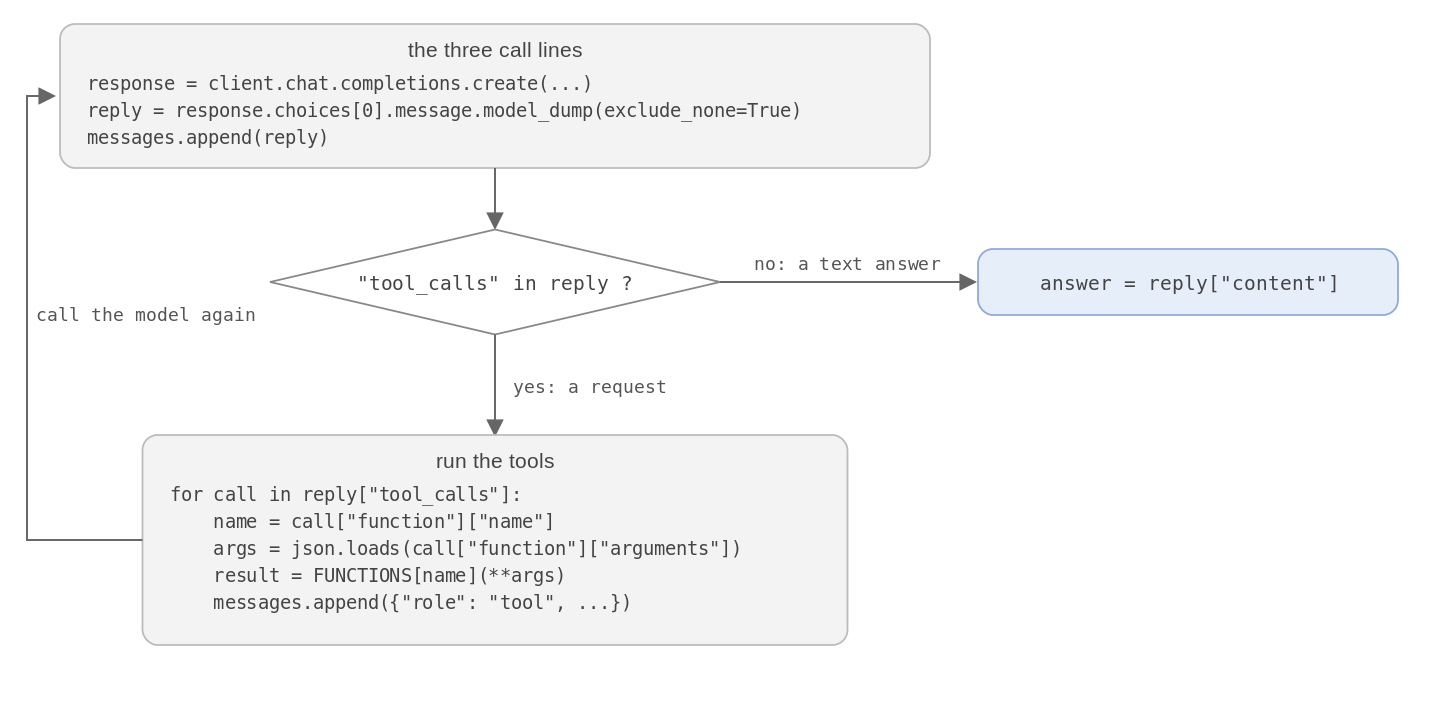

- `FUNCTIONS` maps each name to its Python function. `**args` passes a dictionary as keyword arguments: `get_weather(**{"city": "Seoul"})` is `get_weather(city="Seoul")`.
- `tool_call_id` links a result to its request. The API rejects a tool message whose request is not in the list, so the reply with the request must be kept first, which the call lines always do.

### 5.1 The function

`get_weather(city)` returns a city's current temperature from Open-Meteo, a free weather service (no key).

*Do:* run the cell.

In [ ]:
# ▶ RUN · example: read each line, then run
import requests

def get_weather(city: str):
    """Get the current temperature of a city in Celsius.

    Args:
        city: City name in English, for example "Seoul".
    """
    try:                                                    # on a network or lookup error, return the error as text
        place = requests.get("https://geocoding-api.open-meteo.com/v1/search",
                             params={"name": city, "count": 1}, timeout=10).json()["results"][0]   # first match
        weather = requests.get("https://api.open-meteo.com/v1/forecast",
                               params={"latitude": place["latitude"], "longitude": place["longitude"],
                                       "current": "temperature_2m"}, timeout=10).json()
        return {"city": place["name"], "temperature_c": weather["current"]["temperature_2m"]}
    except Exception as error:
        return "error: " + str(error)

get_weather("Seoul")

### 5.2 The tool schema

The model cannot read Python code; it reads a schema, a dictionary with this shape:

```python
{"type": "function",
 "function": {"name": "get_weather",                                   # the function's name
              "description": "Get the current temperature of ...",     # the docstring's first line
              "parameters": {"type": "object",
                             "properties": {"city": {"type": "string",               # from  city: str
                                                     "description": "City name ..."}},  # from the Args: line
                             "required": ["city"]}}}
```

Everything in it comes from the function, so `tool_from_function` builds it for any function written in this docstring format.

*Do:* run the two cells (the first only defines the helper) and match each entry with the function.

In [ ]:
# ▶ RUN · setup: just run
import inspect

PYTHON_TO_JSON = {str: "string", int: "integer", float: "number", bool: "boolean"}

def tool_from_function(function):
    """Build a tool schema from a function's name, docstring, and type annotations."""
    doc = inspect.getdoc(function)                        # the docstring, indentation removed
    arg_help = {}
    for line in doc.split("\n"):                          # "name: description" lines under Args:
        line = line.strip()
        if ":" in line and not line.endswith(":"):
            name, text = line.split(":", 1)
            arg_help[name.strip()] = text.strip()
    properties = {}
    for name, parameter in inspect.signature(function).parameters.items():   # each parameter and its annotation
        properties[name] = {"type": PYTHON_TO_JSON[parameter.annotation], "description": arg_help[name]}
    return {
        "type": "function",
        "function": {
            "name": function.__name__,                    # the function's own name
            "description": doc.split("\n")[0],            # the docstring's first line
            "parameters": {"type": "object", "properties": properties, "required": list(properties)},
        },
    }

In [ ]:
# ▶ RUN · example: read each line, then run
TOOLS = [tool_from_function(get_weather)]          # TOOL SCHEMAS, sent with tools=TOOLS
FUNCTIONS = {"get_weather": get_weather}           # name -> Python function
print(json.dumps(TOOLS[0], indent=2))              # indent=2 prints the dictionary on several lines

### 5.3 Call, check, call, check

Five cells: the list, then call, check, call, check. The two call cells are the same code, and so are the two check cells. The first reply has `"tool_calls"`, so the first check runs the tools; the second reply has `"content"`, so the second check reads the answer.

*Do:* run the cells in order. Look at the keys in each printed `reply`, and watch the list grow 2 → 3 → 4 → 5.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - the list
WEATHER_SYSTEM = "You answer questions about the weather. Use the tools for current values; never guess them."
QUESTION = "What is the temperature in Seoul right now?"

messages = [
    {"role": "system", "content": WEATHER_SYSTEM},   # SYSTEM message
    {"role": "user", "content": QUESTION},           # USER message
]
answer = None
show_messages(messages)

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 2 - call the model
response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)                               # ASSISTANT message
print(reply)                                         # which key does it have?
show_messages(messages)

**Reading the output.** This `reply` has no `"content"` key. It has `"tool_calls"` instead, so it is a request:

```python
{'role': 'assistant',
 'annotations': [],
 'tool_calls': [                                         # a list: one reply may hold several requests
     {'id': 'call_SOdeABsx...',                          # the request's id; its result must carry it
      'function': {'arguments': '{"city":"Seoul"}',      # the arguments, as JSON text
                   'name': 'get_weather'},               # which function to run
      'type': 'function'}]}
```

Your id and numbers will differ from run to run; the keys are always the same. The tool-running lines read exactly these parts: `call["function"]["name"]`, `json.loads(call["function"]["arguments"])`, and `call["id"]`. `show_messages` prints a request as its `function` part: `{'arguments': '{"city":"Seoul"}', 'name': 'get_weather'}`. Nothing has run yet: the temperature is nowhere in the list.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 3 - check the key, run the tools
if "tool_calls" in reply:
    for call in reply["tool_calls"]:
        name = call["function"]["name"]
        args = json.loads(call["function"]["arguments"])
        result = FUNCTIONS[name](**args)
        messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})   # TOOL message
else:
    answer = reply["content"]
print("answer:", answer)
show_messages(messages)

**Reading the output.** The check took the `"tool_calls"` branch: it ran `get_weather(city="Seoul")` and added one tool message. `answer` is still `None`, because no text answer has arrived yet. The new message:

```python
{'role': 'tool',
 'tool_call_id': 'call_SOdeABsx...',                     # the same id as the request in [2]
 'content': '{"city": "Seoul", "temperature_c": 19.7}'}  # the result as JSON text, made by json.dumps
```

The id pairs this result with its request. A message's content is text, so `json.dumps` turns the result into JSON text; `show_messages` prints that text as it is.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 4 - call the model (the same code as unit 2)
response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)                               # ASSISTANT message
print(reply)                                         # which key does it have?
show_messages(messages)

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 5 - check the key, run the tools (the same code as unit 3)
if "tool_calls" in reply:
    for call in reply["tool_calls"]:
        name = call["function"]["name"]
        args = json.loads(call["function"]["arguments"])
        result = FUNCTIONS[name](**args)
        messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})   # TOOL message
else:
    answer = reply["content"]
print("answer:", answer)
show_messages(messages)

**Reading the output.** The second `reply` had `"content"`, so the check took the `else` branch and set `answer`. The list now shows the whole round trip:

| Position | Role | Written by | Holds |
|---|---|---|---|
| `[0]` | system | you | the standing instruction |
| `[1]` | user | you | the question |
| `[2]` | assistant | the model, kept as it arrived | the request: `get_weather` with `{"city": "Seoul"}` |
| `[3]` | tool | your program | the result, linked to `[2]` by its id |
| `[4]` | assistant | the model, kept as it arrived | the answer, written from `[3]` |

The model never ran anything. It asked in `[2]`; your code ran the function and wrote `[3]`; the model read `[3]` in the next call.

### 5.4 ✍️ The same cells for Tokyo

*Do:* the cells are given except the line that keeps the reply in each call cell, and the two lines that run the function and add its result in each check cell. Each cell prints the list. Afterwards, try a question that needs no tool ("Say hello"): the first reply already has `"content"`.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - the list
QUESTION = "What is the temperature in Tokyo right now?"
messages = [
    {"role": "system", "content": WEATHER_SYSTEM},
    {"role": "user", "content": QUESTION},
]
answer = None
show_messages(messages)

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
## Unit 2 - call the model
response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
reply = response.choices[0].message.model_dump(exclude_none=True)
### FILL IN (START) ###
# keep the reply in the list
### FILL IN (END) ###

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)                  # expected: 3 messages, the last one a request

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
## Unit 3 - check the key, run the tools
if "tool_calls" in reply:
    for call in reply["tool_calls"]:
        name = call["function"]["name"]
        args = json.loads(call["function"]["arguments"])
        ### FILL IN (START) ###
        pass    # run the function, then add its result as a tool message
        ### FILL IN (END) ###
else:
    answer = reply["content"]

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)                  # expected: 4 messages, the last one a result

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
## Unit 4 - call the model
response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
reply = response.choices[0].message.model_dump(exclude_none=True)
### FILL IN (START) ###
# keep the reply in the list
### FILL IN (END) ###

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)                  # expected: 5 messages, the last one the answer

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
## Unit 5 - check the key, run the tools
if "tool_calls" in reply:
    for call in reply["tool_calls"]:
        name = call["function"]["name"]
        args = json.loads(call["function"]["arguments"])
        ### FILL IN (START) ###
        pass    # run the function, then add its result as a tool message
        ### FILL IN (END) ###
else:
    answer = reply["content"]

In [ ]:
# ▶ RUN · check: just run
print("answer:", answer)
roles = []
for m in messages:
    roles.append(m["role"])
found = False
if answer is not None and isinstance(result, dict) and result["city"] == "Tokyo":
    value = result["temperature_c"]
    if str(value) in answer:
        found = True
    if value == round(value) and str(round(value)) in answer:   # 21.0 may be written as 21
        found = True
done["5.4"] = roles == ["system", "user", "assistant", "tool", "assistant"] and found
done["5.4"]

## 6. The Agent Loop

Part 5 was call, check, call, check. Put the two in a loop and stop when the check finds a text answer: that is the **agent loop**. The model picks the next action from everything in the list, the program runs it, and the result joins the next call. The only new lines are the `for` and the `break`.

```python
messages = [{"role": "system", "content": CALC_SYSTEM}, {"role": "user", "content": QUESTION}]
answer = None
for step in range(MAX_STEPS):                    # a limit, so the loop always ends
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
    reply = response.choices[0].message.model_dump(exclude_none=True)
    messages.append(reply)
    if "tool_calls" in reply:
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = FUNCTIONS[name](**args)
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})
    else:
        answer = reply["content"]
        break                                    # a text answer: stop
```

### 6.1 A calculator tool

One tool, `calculate(expression)`: the model writes the whole arithmetic expression, and `eval` runs it as Python, for example `eval("58 * 94 + 37 * 21")` returns `6229`. `eval` runs whatever Python text it receives, so the second argument, `{"__builtins__": {}}`, removes Python's built-in functions (such as `open`) and leaves only arithmetic. That is enough for this practice but not a real safeguard; Ch. 14 returns to running model-written code. A bad expression returns the error as text, as `get_weather` does.

*Do:* run the cell; it prints two results.

In [ ]:
# ▶ RUN · example: read each line, then run
def calculate(expression: str):
    """Evaluate an arithmetic expression and return the result.

    Args:
        expression: A Python arithmetic expression, for example "58 * 94 + 37 * 21".
    """
    try:
        return eval(expression, {"__builtins__": {}})     # run the text as Python, with no built-in functions
    except Exception as error:
        return "error: " + str(error)

CALC_SYSTEM = "You are a careful calculator. Use the calculate tool for every calculation; never compute in your head."
MAX_STEPS = 6
TOOLS = [tool_from_function(calculate)]
FUNCTIONS = {"calculate": calculate}
print(calculate("58 * 94 + 37 * 21"))
print(calculate("open('file.txt')"))                       # blocked: no built-in functions

### 6.2 Run the loop

*Do:* run the cell. The list shows the request with the expression the model wrote, its result, and the final answer.

In [ ]:
# ▶ RUN · example: read each line, then run
QUESTION = "What is (4817 × 293) + 1569?"
messages = [{"role": "system", "content": CALC_SYSTEM}, {"role": "user", "content": QUESTION}]
answer = None
for step in range(MAX_STEPS):
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
    reply = response.choices[0].message.model_dump(exclude_none=True)
    messages.append(reply)
    if "tool_calls" in reply:
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = FUNCTIONS[name](**args)
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})
    else:
        answer = reply["content"]
        break
show_messages(messages)
print("answer:", answer)

**Reading the output.** Each pass of the loop adds one reply, and then one tool message for each request in it. In a typical run:

| Step | Added to the list | Branch taken |
|---|---|---|
| 0 | `[2]` request `calculate` with `{"expression": "(4817 * 293) + 1569"}`, `[3]` its result | `"tool_calls"`: run, add the result |
| 1 | `[4]` the text answer, written from `[3]` | `else`: set `answer`, `break` |

The model turned `×` into `*` and wrote the whole expression in one request; `eval` computed it. With more steps (6.4 and Part 7) the loop simply runs more passes. If one reply holds several requests, the inner `for` adds one tool message for each in the same step.

### 6.3 ✍️ Write the loop's two appends

*Do:* the loop is given except the line that keeps the reply and the line that adds a result. Expected answer: 6229.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
QUESTION = "What is (58 × 94) + (37 × 21)?"
messages = [{"role": "system", "content": CALC_SYSTEM}, {"role": "user", "content": QUESTION}]
answer = None
for step in range(MAX_STEPS):
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
    reply = response.choices[0].message.model_dump(exclude_none=True)
    ### FILL IN (START) ###
    # keep the reply in the list
    ### FILL IN (END) ###
    if "tool_calls" in reply:
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = FUNCTIONS[name](**args)
            ### FILL IN (START) ###
            # add the result as a tool message
            ### FILL IN (END) ###
    else:
        answer = reply["content"]
        break

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)
done["6.3"] = answer is not None and ("6229" in answer or "6,229" in answer)
done["6.3"]

### 6.4 ✍️ Weather and calculator together

Registering a tool is one item in `TOOLS` and one entry in `FUNCTIONS`. With the weather tool and `calculate` together, the model can answer a question that needs a lookup and then arithmetic.

*Do:* the loop is given; complete the registration: `TOOLS` needs the schema for `calculate` too, and `FUNCTIONS` its name. Expected: two requests in two steps, `get_weather` and then `calculate`.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
MIXED_SYSTEM = "Use get_weather for current temperatures and calculate for every calculation; never compute in your head."
QUESTION = "What is the current temperature in Seoul in Fahrenheit? Use F = C × 1.8 + 32."
### FILL IN (START) ###
TOOLS = [tool_from_function(get_weather)]            # add the schema for calculate
FUNCTIONS = {"get_weather": get_weather}             # add its name and function
### FILL IN (END) ###
messages = [{"role": "system", "content": MIXED_SYSTEM}, {"role": "user", "content": QUESTION}]
answer = None
for step in range(MAX_STEPS):
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
    reply = response.choices[0].message.model_dump(exclude_none=True)
    messages.append(reply)
    if "tool_calls" in reply:
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = FUNCTIONS[name](**args)
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})
    else:
        answer = reply["content"]
        break

In [ ]:
# ▶ RUN · check: just run
show_messages(messages)
requested = []
for m in messages:
    if "tool_calls" in m:                            # replies that hold requests
        for call in m["tool_calls"]:
            requested.append(call["function"]["name"])
done["6.4"] = "get_weather" in requested and "calculate" in requested and answer is not None
done["6.4"]

## 7. ReAct: a Thought before Each Action

ReAct has the model write a **Thought** (what the results show, what is missing, why the next action) before each **Action**; the tool's result is the **Observation**.

A request carries only a function name and arguments, so there is no place for a thought. The simple fix: give each tool a first argument named `thought`. The model must fill it in every request, so the reason arrives together with the action.

The loop is Part 6's loop unchanged, with one more argument: `parallel_tool_calls=False` asks for one request per reply, so each thought is written after the previous observation.

### 7.1 Tools that ask for a thought

*Do:* run the two cells. The first defines a plain Wikipedia search (no key). The second wraps search and weather as tools whose first argument is `thought`, and prints the search tool's schema.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - a plain Wikipedia search
import html

def wikipedia_search(query: str):
    """Search Wikipedia and return the top three results: title and a short snippet.

    Args:
        query: Search words, for example "Gyeongbokgung Palace".
    """
    try:
        data = requests.get("https://en.wikipedia.org/w/api.php",
                            params={"action": "query", "list": "search", "srsearch": query,
                                    "srlimit": 3, "format": "json"},
                            headers={"User-Agent": "STML-course-practice/1.0"}, timeout=10).json()
        lines = []
        for item in data["query"]["search"]:
            snippet = item["snippet"].replace('<span class="searchmatch">', "").replace("</span>", "")   # drop highlight tags
            lines.append(item["title"] + " | " + html.unescape(snippet))                               # &#039; -> '
        return "\n".join(lines)
    except Exception as error:                     # a failed search is returned as text, not raised
        return "error: " + str(error)

print(wikipedia_search("Gyeongbokgung Palace"))

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 2 - tools whose first argument is the thought
def search(thought: str, query: str):
    """Search Wikipedia and return the top three results.

    Args:
        thought: Your reasoning: what the results so far show, what is still missing, and why this search.
        query: Search words, for example "Gyeongbokgung Palace".
    """
    print("Thought:", thought)
    return wikipedia_search(query)

def check_weather(thought: str, city: str):
    """Get the current temperature of a city in Celsius.

    Args:
        thought: Your reasoning: what the results so far show, what is still missing, and why this lookup.
        city: City name in English, for example "Seoul".
    """
    print("Thought:", thought)
    return get_weather(city)

TOOLS = [tool_from_function(search), tool_from_function(check_weather)]
FUNCTIONS = {"search": search, "check_weather": check_weather}
print(json.dumps(TOOLS[0], indent=2))

### 7.2 The same loop, one request per reply

*Do:* run the cell. Each tool prints its Thought when it runs; the list afterwards shows each request (with its thought) and its result. Expected: a search that finds Seoul, then `check_weather` for Seoul.

In [ ]:
# ▶ RUN · example: read each line, then run
TRAVEL_SYSTEM = "You help travellers. Use search to find the city of any place before checking its weather."
QUESTION = "I am visiting Gyeongbokgung Palace this afternoon. What is the temperature there right now?"

messages = [{"role": "system", "content": TRAVEL_SYSTEM}, {"role": "user", "content": QUESTION}]
answer = None
for step in range(MAX_STEPS):
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS,
                                              parallel_tool_calls=False)   # one request per reply
    reply = response.choices[0].message.model_dump(exclude_none=True)
    messages.append(reply)
    if "tool_calls" in reply:
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = FUNCTIONS[name](**args)                             # the tool prints its thought
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})
    else:
        answer = reply["content"]
        break
show_messages(messages)
print("answer:", answer)

**Reading the output.** The `Thought:` lines were printed by the tools as they ran. In the list, each part of ReAct has its own place:

| ReAct | Where it is in the list |
|---|---|
| Thought | inside a request's arguments: `"thought": "I need to find out which city ..."` (`[2]`, `[4]`) |
| Action | the same request: the function name and its other arguments |
| Observation | the tool message right after it (`[3]`, `[5]`) |

The second Thought ("... located in Seoul, so I will check ...") uses the Observation in `[3]`. That is why `parallel_tool_calls=False` matters: each request is written after the previous result is in the list.

### 7.3 ✍️ Read one step

*Do:* choose one result and the Thought after it. In `reading`, write which fact from the result the Thought used, and whether the next action follows from it. (Not checked.)

In [ ]:
# ✍️ WRITE · your answer in words (not checked)
reading = """

"""

## 8. The Agent as a Class

A loop written in a cell starts a new `messages` list each time, so a follow-up ("And in Busan?") has nothing to refer to. A **class** keeps the list inside an object and gives names to the code you already wrote. These named pieces are **methods**, functions that belong to the object:

| Method | What it does | The code from |
|---|---|---|
| `call_model()` | calls the model with the list, keeps the reply, returns it | Part 1: the three call lines |
| `run_tools(reply)` | runs each request in the reply and adds each result | Part 5: the tool-running lines |
| `ask(question)` | adds the question, then loops: call the model, check the key, run the tools or return the answer | Part 6: the loop |
| `show()` | prints the object's list | `show_messages` |

`self` is the object itself; `self.messages` is a value stored in it (an **attribute**) that stays between calls. An `Agent` made without functions has no tools, so every reply has `"content"`: it is a plain conversation.

### 8.1 The class

*Do:* run the cell. Find in each method the lines you wrote in Parts 1, 5, and 6.

In [ ]:
# ▶ RUN · example: read each line, then run
class Agent:
    """A model with its own message list and, optionally, tools."""

    def __init__(self, system, functions=[]):
        self.messages = [{"role": "system", "content": system}]              # SYSTEM message, once
        self.tools = []                                                      # TOOL SCHEMAS
        self.functions = {}                                                  # name -> Python function
        for function in functions:
            self.tools.append(tool_from_function(function))
            self.functions[function.__name__] = function

    def call_model(self):
        """Call the model with the list; keep the reply and return it."""
        if len(self.tools) > 0:
            response = client.chat.completions.create(model=MODEL, messages=self.messages, tools=self.tools)
        else:                                                                # no tools: the API rejects an empty list
            response = client.chat.completions.create(model=MODEL, messages=self.messages)
        reply = response.choices[0].message.model_dump(exclude_none=True)
        self.messages.append(reply)                                          # ASSISTANT message
        return reply

    def run_tools(self, reply):
        """Run each request in the reply and add each result as a tool message."""
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = self.functions[name](**args)
            self.messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})   # TOOL message

    def ask(self, question, max_steps=6):
        """Add the question, then loop until the model answers in text."""
        self.messages.append({"role": "user", "content": question})          # USER message
        for step in range(max_steps):
            reply = self.call_model()
            if "tool_calls" in reply:                                        # requests: run the tools
                self.run_tools(reply)
            else:                                                            # a text answer: done
                return reply["content"]
        return None                                                          # the step limit ended the loop

    def show(self):
        """Print this object's messages."""
        show_messages(self.messages)

### 8.2 One step at a time

The methods can also be called one by one. These cells are the 5.3 cells, with the object doing the work: `call_model()` replaces the three call lines, and `run_tools(reply)` replaces the tool-running lines. The key check stays in the cell.

*Do:* run the cells in order and compare each list with 5.3.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - create the agent and add the question
weather = Agent(WEATHER_SYSTEM, [get_weather])
weather.messages.append({"role": "user", "content": "What is the temperature in Seoul right now?"})   # USER message
answer = None
weather.show()

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 2 - call the model
reply = weather.call_model()
print(reply)                                         # which key does it have?
weather.show()

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 3 - check the key, run the tools
if "tool_calls" in reply:
    weather.run_tools(reply)
else:
    answer = reply["content"]
print("answer:", answer)
weather.show()

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 4 - call the model (the same code as unit 2)
reply = weather.call_model()
print(reply)
weather.show()

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 5 - check the key, run the tools (the same code as unit 3)
if "tool_calls" in reply:
    weather.run_tools(reply)
else:
    answer = reply["content"]
print("answer:", answer)
weather.show()

**Reading the output.** The same five messages as in 5.3: system, user, the request, the tool result, the answer. The code in each cell is shorter because the methods hold the lines; what happens is the same.

### 8.3 `ask`: the whole loop in one call

*Do:* run the two cells. The second question only makes sense after the first: its messages sit below the first question's, and the difference uses Seoul's temperature from there.

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 1 - create the agent and ask the first question
agent = Agent(MIXED_SYSTEM, [get_weather, calculate])
agent.ask("What is the temperature in Seoul right now?")
agent.show()

In [ ]:
# ▶ RUN · example: read each line, then run
## Unit 2 - a follow-up that needs the first answer
agent.ask("And in Busan? How many degrees warmer or colder is Busan than Seoul?")
agent.show()

**Reading the output.** The follow-up's messages start below the first question's. To compare Busan with Seoul, the model did not look Seoul up again: it used the Seoul result that is still in `agent.messages`. A result with a long tail of digits, such as `2.3999999999999986` for 22.0 − 19.6, is ordinary floating-point rounding; the model rounds it in the answer.

### 8.4 An agent without tools

*Do:* run the cell. `Agent(STAFF_SYSTEM)` gets no functions, so `call_model` sends no tools and every reply has `"content"`. Compare the list with 2.1.

In [ ]:
# ▶ RUN · example: read each line, then run
chat = Agent(STAFF_SYSTEM)
chat.ask("A customer ordered 2 mugs and 1 desk lamp. List the items in the order.")
chat.ask("The lamp was cancelled. What is left in the order?")
chat.show()

**Reading the output.** The list alternates user and assistant messages, as in 2.1. With no tools, `ask` returned at the first pass of its loop each time.

### 8.5 ✍️ Complete the class

*Do:* `MyAgent` is the `Agent` class with three lines missing: in `call_model`, the line that keeps the reply; in `run_tools`, the line that adds a result; in `ask`, the line that runs the tools. The check converts two temperatures. Expected: 86 and 53.6.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
CONVERTER_SYSTEM = "You convert Celsius to Fahrenheit with F = C × 1.8 + 32. Use the calculate tool for every calculation."
class MyAgent:
    def __init__(self, system, functions=[]):
        self.messages = [{"role": "system", "content": system}]
        self.tools = []
        self.functions = {}
        for function in functions:
            self.tools.append(tool_from_function(function))
            self.functions[function.__name__] = function

    def call_model(self):
        if len(self.tools) > 0:
            response = client.chat.completions.create(model=MODEL, messages=self.messages, tools=self.tools)
        else:
            response = client.chat.completions.create(model=MODEL, messages=self.messages)
        reply = response.choices[0].message.model_dump(exclude_none=True)
        ### FILL IN (START) ###
        # keep the reply
        ### FILL IN (END) ###
        return reply

    def run_tools(self, reply):
        for call in reply["tool_calls"]:
            name = call["function"]["name"]
            args = json.loads(call["function"]["arguments"])
            result = self.functions[name](**args)
            ### FILL IN (START) ###
            # add the result as a tool message
            ### FILL IN (END) ###

    def ask(self, question, max_steps=6):
        self.messages.append({"role": "user", "content": question})
        for step in range(max_steps):
            reply = self.call_model()
            if "tool_calls" in reply:
                ### FILL IN (START) ###
                pass    # run the tools
                ### FILL IN (END) ###
            else:
                return reply["content"]
        return None

    def show(self):
        show_messages(self.messages)

In [ ]:
# ▶ RUN · check: just run
converter = MyAgent(CONVERTER_SYSTEM, [calculate])
answer_30 = converter.ask("Convert 30 °C to Fahrenheit.")
answer_12 = converter.ask("And 12 °C?")
converter.show()
roles = []
for m in converter.messages:
    roles.append(m["role"])
done["8.5"] = "86" in str(answer_30) and "53.6" in str(answer_12) and "tool" in roles
done["8.5"]

### 8.6 ✍️ Two agents working together

An advisor answers, a reviewer comments, the advisor revises. The reviewer is an `Agent` without tools; its **system** message is `REVIEW_SYSTEM`. The answer reaches it in a **user** message, and the review goes back to the advisor in another **user** message. Each object keeps its own list, so "revise your answer" is enough.

*Do:* the two objects and the first answer are given; write the two `ask` lines: the reviewer receives the question and the answer, and the advisor receives the review.

In [ ]:
# ✍️ TYPE · exercise: write the code between the FILL IN lines yourself
REVIEW_SYSTEM = ("You review weather advice. Point out anything missing, such as the actual temperature "
                 "or a clear recommendation. Answer in at most three sentences.")
QUESTION = "Should I take a jacket for a walk in Seoul right now?"
advisor = Agent(WEATHER_SYSTEM, [get_weather])
reviewer = Agent(REVIEW_SYSTEM)
answer = advisor.ask(QUESTION)
### FILL IN (START) ###
review = ""     # ask the reviewer with a message that holds QUESTION and answer
revised = ""    # ask the advisor to revise, with a message that holds review
### FILL IN (END) ###

In [ ]:
# ▶ RUN · check: just run
reviewer.show()                                      # the answer reached the reviewer as a USER message
print("REVISED:", revised)
advisor_questions = 0
for m in advisor.messages:
    if m["role"] == "user":
        advisor_questions = advisor_questions + 1
done["8.6"] = advisor_questions == 2 and len(reviewer.messages) == 3 and revised != ""
done["8.6"]

## Summary

Every call in this notebook was the same three call lines, followed by a check of the key. In a class, the two longer pieces are the methods `call_model()` and `run_tools(reply)`:

```python
response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
reply = response.choices[0].message.model_dump(exclude_none=True)
messages.append(reply)
if "tool_calls" in reply:
    for call in reply["tool_calls"]:
        name = call["function"]["name"]
        args = json.loads(call["function"]["arguments"])
        result = FUNCTIONS[name](**args)
        messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})
else:
    answer = reply["content"]
```

*Do:* run the cell; redo any `False` item.

In [ ]:
# ▶ RUN · setup: just run
for key in done:
    print(key, done[key])